In [1]:
!pip install fairlearn
!pip install catboost
!pip install category_encoders

In [2]:
from fairlearn.datasets import fetch_acs_income

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer

In [5]:
#algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,  #
    Lasso,  #
    ElasticNet,
    SGDRegressor,
    BayesianRidge,
    ARDRegression
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,  #
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  #
from lightgbm import LGBMRegressor  #
from catboost import CatBoostRegressor  #



In [6]:
#testing imports
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    explained_variance_score
)
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit


In [7]:
import xgboost as xgb
import lightgbm as lgb

In [8]:
acs_income_ds = fetch_acs_income();

income_df = acs_income_ds.frame;
print(income_df.head());
print(income_df.tail());
#no missing records, values are numeric
print(income_df.info());

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
0  18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0   1600.0
1  53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  10000.0
2  41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  24000.0
3  18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0    180.0
4  21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  29000.0
         AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
1664495  39.0  6.0  16.0  5.0  6260.0  72.0   0.0  20.0  1.0    1.0   9600.0
1664496  38.0  6.0  14.0  5.0  4251.0  72.0   0.0  32.0  1.0    8.0   2400.0
1664497  37.0  1.0  19.0  3.0  7750.0  17.0  13.0  40.0  2.0    9.0  19700.0
1664498  47.0  1.0  16.0  1.0  8990.0  72.0   1.0  40.0  1.0    8.0  18700.0
1664499  34.0  1.0  16.0  5.0  6260.0  72.0   2.0  40.0  1.0    1.0   7900.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664500 entries, 0 to 1664499
Data columns (total 11 columns):

50th percentile: $39,000
75th percentile: $68,000
90th percentile: $112,000
95th percentile: $157,000
99th percentile: $432,000
99.9th percentile: $698,000


<function matplotlib.pyplot.show(close=None, block=None)>

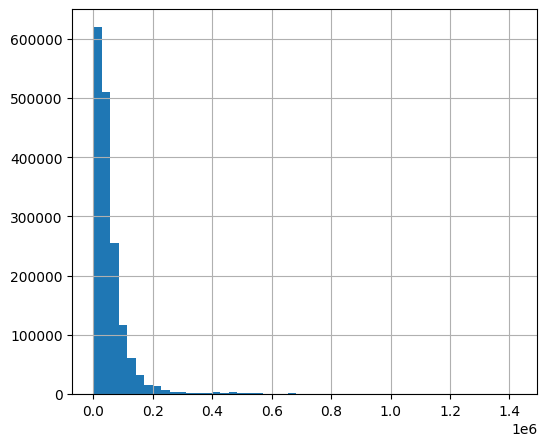

In [9]:
#addressing outliers
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"{p}th percentile: ${np.percentile(income_df['PINCP'], p):,.0f}")

income_df['PINCP'].hist(figsize=(6,5), bins=50)
plt.show

In [10]:
income_df_rm_out = income_df.copy()

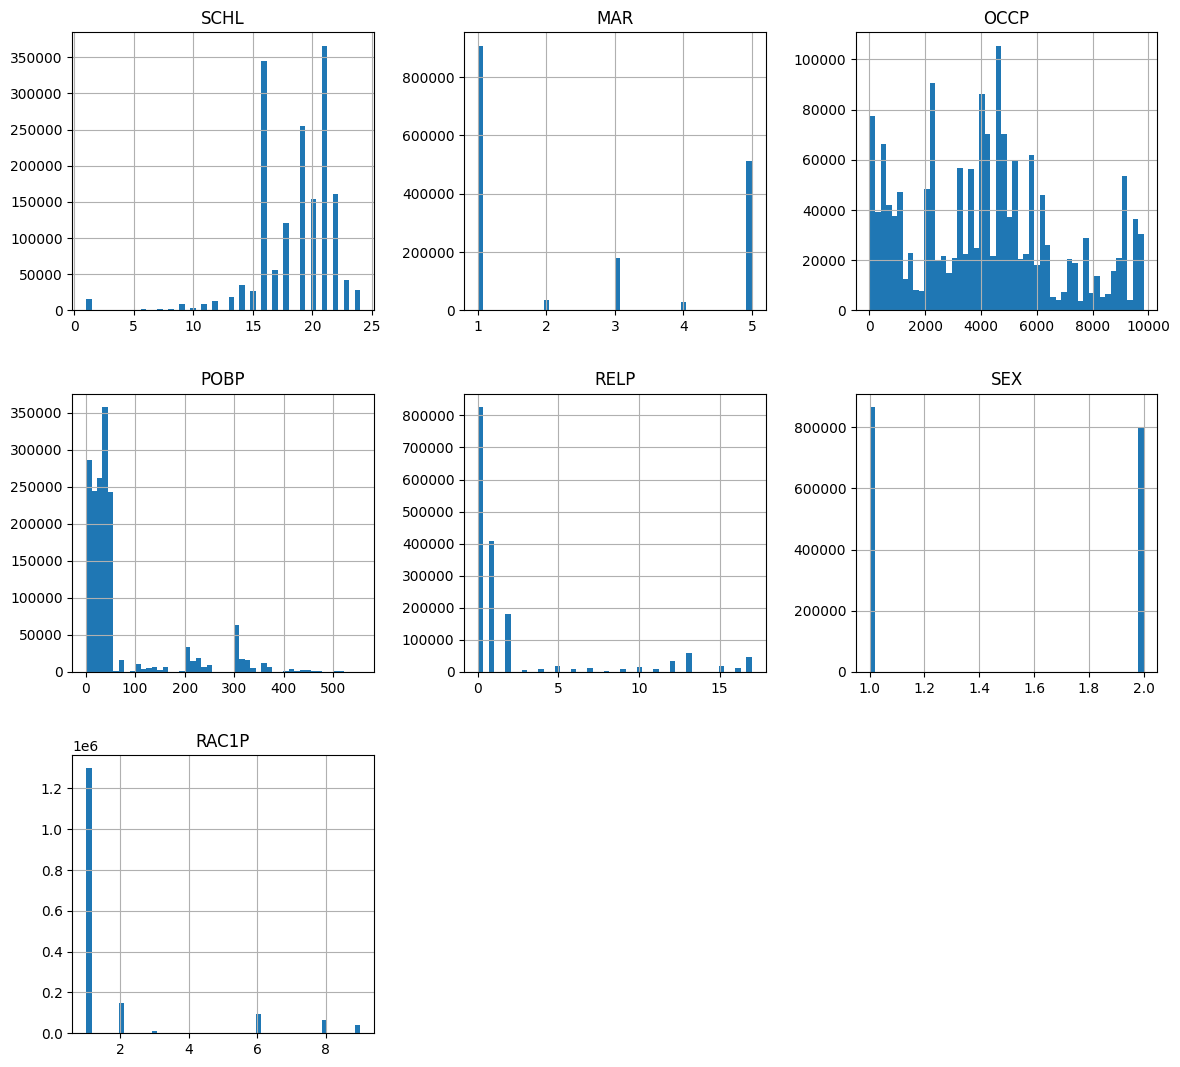

In [11]:
#show class imbalance
cols = ['SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'SEX', 'RAC1P']

income_df[cols].hist(bins=50, figsize=(14, 13))
plt.show()

In [12]:
print(income_df_rm_out.head())
print(income_df_rm_out.tail())
print(income_df_rm_out['PINCP'].describe())

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
0  18.0  1.0  18.0  5.0  4720.0  13.0  17.0  21.0  2.0    2.0   1600.0
1  53.0  5.0  17.0  5.0  3605.0  18.0  16.0  40.0  1.0    1.0  10000.0
2  41.0  1.0  16.0  5.0  7330.0   1.0  17.0  40.0  1.0    1.0  24000.0
3  18.0  6.0  18.0  5.0  2722.0   1.0  17.0   2.0  2.0    1.0    180.0
4  21.0  5.0  19.0  5.0  3870.0  12.0  17.0  50.0  1.0    1.0  29000.0
         AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P    PINCP
1664495  39.0  6.0  16.0  5.0  6260.0  72.0   0.0  20.0  1.0    1.0   9600.0
1664496  38.0  6.0  14.0  5.0  4251.0  72.0   0.0  32.0  1.0    8.0   2400.0
1664497  37.0  1.0  19.0  3.0  7750.0  17.0  13.0  40.0  2.0    9.0  19700.0
1664498  47.0  1.0  16.0  1.0  8990.0  72.0   1.0  40.0  1.0    8.0  18700.0
1664499  34.0  1.0  16.0  5.0  6260.0  72.0   2.0  40.0  1.0    1.0   7900.0
count    1.664500e+06
mean     5.666386e+04
std      7.306745e+04
min      1.040000e+02
25%      2.000000e+04
50

In [13]:
income_df_rm_out_group = income_df_rm_out.copy()

In [14]:
print(income_df_rm_out_group['SEX'].value_counts())

SEX
1.0    866735
2.0    797765
Name: count, dtype: int64


In [15]:
print(income_df_rm_out['COW'].value_counts())

COW
1.0    1094831
2.0     141681
3.0     117822
6.0     109442
4.0      80413
7.0      65311
5.0      49714
8.0       5286
Name: count, dtype: int64


In [16]:
def map_race(x):
    if x == 1:
        return "white"
    elif x == 2:
        return "black"
    elif x == 6:
        return "asian"
    elif x in [3, 4, 5]:
        return "indigenous"
    elif x == 7:
        return "pacific"
    elif x == 8:
        return "other"
    elif x == 9:
        return "multi"
    else:
        return "unknown"

income_df_rm_out_group["RAC1P_GROUP"] = income_df_rm_out["RAC1P"].apply(map_race)
income_df_rm_out = income_df_rm_out.dropna(subset=['RAC1P'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['RAC1P_GROUP'])

print(income_df_rm_out['RAC1P'].value_counts())
print(income_df_rm_out_group['RAC1P_GROUP'].value_counts())

income_df_rm_out_group.drop('RAC1P', axis=1, inplace=True)

RAC1P
1.0    1298126
2.0     147573
6.0      96399
8.0      62877
9.0      41815
3.0      11887
7.0       2813
5.0       2104
4.0        906
Name: count, dtype: int64
RAC1P_GROUP
white         1298126
black          147573
asian           96399
other           62877
multi           41815
indigenous      14897
pacific          2813
Name: count, dtype: int64


In [17]:
def map_relp(x):
    if x == 0:
        return "reference"
    elif x == 1:
        return "spouse"
    elif x in [2, 3, 4, 7, 14]:
        return "child_dep"
    elif x in [6, 8]:
        return "parent"
    elif x in [5, 9, 10]:
        return "extended_family"
    elif x in [11, 12, 13]:
        return "non_family"
    elif x == 15:
        return "other"
    elif x in [16, 17]:
        return "group_quarters"
    else:
        return "unknown"


income_df_rm_out_group["RELP_GROUP"] = income_df_rm_out["RELP"].apply(map_relp)
income_df_rm_out = income_df_rm_out.dropna(subset=['RELP'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['RELP_GROUP'])

print(income_df_rm_out['RELP'].value_counts())
print(income_df_rm_out_group['RELP_GROUP'].value_counts())

income_df_rm_out_group.drop('RELP', axis=1, inplace=True)

RELP
0.0     826358
1.0     407745
2.0     180269
13.0     58600
17.0     45500
12.0     32393
5.0      17162
15.0     16963
10.0     14306
7.0      11625
16.0     11521
4.0       9949
9.0       9083
6.0       8808
11.0      7834
3.0       4605
8.0       1674
14.0       105
Name: count, dtype: int64
RELP_GROUP
reference          826358
spouse             407745
child_dep          206553
non_family          98827
group_quarters      57021
extended_family     40551
other               16963
parent              10482
Name: count, dtype: int64


In [18]:
#POBP
print(income_df_rm_out_group['POBP'].value_counts())

def map_pobp(p):
    if pd.isna(p):
        return np.nan

    p = int(p)

    # Keep US states as-is
    if 1 <= p <= 56:
        return p

    # Territories (optional separate)
    elif p in {60, 66, 69, 72, 78}:
        return 100

    # Mexico (important to keep separate)
    elif p == 303:
        return 101

    # Other Americas
    elif 300 <= p <= 399:
        return 102

    # Europe
    elif 100 <= p <= 169:
        return 103

    # Asia
    elif 200 <= p <= 254:
        return 104

    # Africa
    elif 400 <= p <= 468:
        return 105

    # Oceania
    elif 500 <= p <= 554:
        return 106

    return np.nan

income_df_rm_out_group['POBP'] = income_df_rm_out_group['POBP'].apply(map_pobp)
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['POBP'])
print(income_df_rm_out_group['POBP'].value_counts())

POBP
6.0      139833
36.0     109586
48.0      92244
42.0      75297
17.0      72554
          ...  
456.0        59
420.0        57
463.0        54
374.0        42
464.0         2
Name: count, Length: 224, dtype: int64
POBP
6.0      139833
36.0     109586
48.0      92244
104.0     84229
42.0      75297
17.0      72554
39.0      69292
102.0     65152
26.0      57489
101.0     57275
12.0      44451
34.0      41337
25.0      37062
103.0     35849
18.0      35634
37.0      34316
13.0      33749
55.0      32858
27.0      31283
51.0      30758
29.0      30682
47.0      26208
53.0      24695
22.0      23070
24.0      22656
21.0      21197
19.0      21176
1.0       21078
8.0       18590
9.0       18531
45.0      17794
40.0      16608
20.0      16487
4.0       16368
100.0     16289
41.0      14524
28.0      14362
49.0      13340
5.0       12546
105.0     11983
31.0      11898
54.0      10382
35.0       8543
23.0       6995
11.0       6951
15.0       6779
16.0       6551
46.0       5870
44.0   

In [19]:
#SCHL
def map_school(s):
    if 1 <= s <= 15:
        return 1.0   # Less than HS
    elif s in [16, 17]:
        return 2.0   # HS or GED
    elif s in [18, 19]:
        return 3.0   # Some college
    elif s == 20:
        return 4.0  # Associate
    elif s == 21:
        return 5.0   # Bachelor
    elif 22 <= s <= 24:
        return 6.0   # Graduate+
    else:
        return 7.0 #other
print(income_df_rm_out['SCHL'].value_counts())
income_df_rm_out_group['SCHL'] = income_df_rm_out['SCHL'].apply(map_school)
print(income_df_rm_out_group['SCHL'].value_counts())

SCHL
21.0    366380
16.0    344823
19.0    255517
22.0    160594
20.0    154281
18.0    121246
17.0     55883
23.0     41426
14.0     34506
24.0     27530
15.0     26938
13.0     19102
1.0      15480
12.0     13219
9.0       9208
11.0      8855
10.0      2674
8.0       2028
6.0       1759
7.0       1281
5.0        764
4.0        419
2.0        325
3.0        262
Name: count, dtype: int64
SCHL
2.0    400682
3.0    376736
5.0    366343
6.0    229515
4.0    154256
1.0    136799
Name: count, dtype: int64


In [20]:
import numpy as np
import pandas as pd

def map_occp_group(code):
    if pd.isna(code):
        return np.nan

    code = int(code)

    if 10 <= code <= 440:
        return "MGR"
    elif 500 <= code <= 750:
        return "BUS"
    elif 800 <= code <= 960:
        return "FIN"
    elif 1005 <= code <= 1240:
        return "CMM"
    elif 1305 <= code <= 1560:
        return "ENG"
    elif 1600 <= code <= 1980:
        return "SCI"
    elif 2001 <= code <= 2060:
        return "CMS"
    elif 2100 <= code <= 2180:
        return "LGL"
    elif 2205 <= code <= 2555:
        return "EDU"
    elif 2600 <= code <= 2920:
        return "ENT"
    elif 3000 <= code <= 3550:
        return "MED"
    elif 3601 <= code <= 3655:
        return "HLS"
    elif 3700 <= code <= 3960:
        return "PRT"
    elif 4000 <= code <= 4160:
        return "EAT"
    elif 4200 <= code <= 4255:
        return "CLN"
    elif 4330 <= code <= 4655:
        return "PRS"
    elif 4700 <= code <= 4965:
        return "SAL"
    elif 5000 <= code <= 5940:
        return "OFF"
    elif 6005 <= code <= 6130:
        return "FFF"
    elif 6200 <= code <= 6765:
        return "CON"
    elif 6800 <= code <= 6950:
        return "EXT"
    elif 7000 <= code <= 7640:
        return "RPR"
    elif 7700 <= code <= 8990:
        return "PRD"
    elif 9005 <= code <= 9760:
        return "TRN"
    elif 9800 <= code <= 9830:
        return "MIL"
    elif code == 9920:
        return "UNEMP"
    else:
        return np.nan

income_df_rm_out_group["OCCP_GROUP"] = income_df_rm_out["OCCP"].apply(map_occp_group)
income_df_rm_out = income_df_rm_out.dropna(subset=['OCCP'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['OCCP_GROUP'])

print(income_df_rm_out['OCCP'].value_counts())
print(income_df_rm_out_group['OCCP_GROUP'].value_counts())

income_df_rm_out_group.drop('OCCP', axis=1, inplace=True)

OCCP
2310.0    44763
440.0     42946
9130.0    38262
4720.0    35495
4760.0    35331
          ...  
7850.0      103
1710.0      102
7830.0       99
510.0        96
6740.0       86
Name: count, Length: 529, dtype: int64
OCCP_GROUP
OFF    192606
MGR    170979
SAL    165711
TRN    123984
EDU    109285
MED    100973
PRD     92258
EAT     88843
CON     78545
CLN     62052
BUS     54114
CMM     50810
RPR     49457
HLS     48889
PRS     48535
FIN     37716
ENT     36235
PRT     35560
ENG     31713
CMS     29265
LGL     18963
SCI     16528
FFF     13253
MIL      5704
EXT      2353
Name: count, dtype: int64


In [21]:
print(income_df_rm_out_group.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1664331 entries, 0 to 1664499
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   AGEP         1664331 non-null  float64
 1   COW          1664331 non-null  float64
 2   SCHL         1664331 non-null  float64
 3   MAR          1664331 non-null  float64
 4   POBP         1664331 non-null  float64
 5   WKHP         1664331 non-null  float64
 6   SEX          1664331 non-null  float64
 7   PINCP        1664331 non-null  float64
 8   RAC1P_GROUP  1664331 non-null  object 
 9   RELP_GROUP   1664331 non-null  object 
 10  OCCP_GROUP   1664331 non-null  object 
dtypes: float64(8), object(3)
memory usage: 152.4+ MB
None


In [22]:
from sklearn.preprocessing import OrdinalEncoder

relp_order = [[
    'group_quarters',   # least typical income structure
    'child_dep',            # dependents
    'unknown',
    'parent',           # often retired
    'other',            # unclear
    'extended_family',
    'non_family',       # roommates / partners
    'spouse',           # secondary earner
    'reference'         # primary earner
]]

ordinal_relp = OrdinalEncoder(categories=relp_order)

income_df_rm_out_group['RELP_GROUP'] = ordinal_relp.fit_transform(
    income_df_rm_out_group[['RELP_GROUP']]
)

In [23]:
race_order = [[
    'indigenous',
    'pacific',
    'black',
    'other',
    'multi',
    'white',
    'asian'
]]

ordinal_race = OrdinalEncoder(categories=race_order)

income_df_rm_out_group['RAC1P_GROUP'] = ordinal_race.fit_transform(
    income_df_rm_out_group[['RAC1P_GROUP']]
)

In [24]:
#encode to float values
ordinal = OrdinalEncoder(categories=[[
    'MGR', 'BUS', 'FIN', 'CMM', 'ENG', 'SCI', 'CMS', 'LGL', 'EDU',
    'ENT', 'MED', 'HLS', 'PRT', 'EAT', 'CLN', 'PRS', 'SAL', 'OFF',
    'FFF', 'CON', 'EXT', 'RPR', 'PRD', 'TRN', 'MIL', 'UNEMP'
]])

income_df_rm_out_group['OCCP_GROUP'] = ordinal.fit_transform(
    income_df_rm_out_group[['OCCP_GROUP']]
)

In [25]:
#One hot encode categorical variables
#adjust this encoding for n-1 variables to account for
#multi-collinearity, the dropped variable should be the
#baseline
income_df_rm_out_group_onehot = pd.get_dummies(
    income_df_rm_out_group,
    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP'],
    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP'],
    dtype=float   #  forces 1.0 / 0.0
)
'''
income_df_rm_out_group_onehot_mc = pd.get_dummies(
    income_df_rm_out_group,
    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],
    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],
    dtype=float,
    drop_first=True
)
'''

"\nincome_df_rm_out_group_onehot_mc = pd.get_dummies(\n    income_df_rm_out_group,\n    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],\n    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],\n    dtype=float,\n    drop_first=True\n)\n"

In [26]:
#Select what modifications to go through with
'''
income_X = income_df.drop(["PINCP"], axis=1);
income_y = income_df["PINCP"].copy();
'''
'''
income_X = income_df_rm_out.drop(["PINCP"], axis=1);
income_y = income_df_rm_out["PINCP"].copy();
'''
'''
income_X = income_df_rm_out_group.drop(["PINCP"], axis=1);
income_y = income_df_rm_out_group["PINCP"].copy();
'''


income_X = income_df_rm_out_group_onehot.drop(["PINCP"], axis=1);
income_y = income_df_rm_out_group_onehot["PINCP"].copy();


In [27]:
#Feature Generation
#there are 3 regression variables that can be combined
#agep
#wkhp
#schl (kind of)
income_X_feat = income_df_rm_out_group.drop(["PINCP"], axis=1);
income_X_feat['WKHPxAGEP'] = income_X['WKHP'] * income_X['AGEP']
income_X_feat['WKHPxSCHL'] = income_X['WKHP'] * income_X['SCHL']
income_X_feat['AGEPxSCHL'] = income_X['AGEP'] * income_X['SCHL']

#non-linearize
#income_X_feat['AGEP2'] = income_X['AGEP'] ** 2
#income_X_feat['WKHP2'] = income_X['WKHP'] ** 2

#income_X_feat.drop(['WKHP', 'POBP'], axis=1, inplace=True)

In [28]:
print(income_y.shape)

(1664331,)


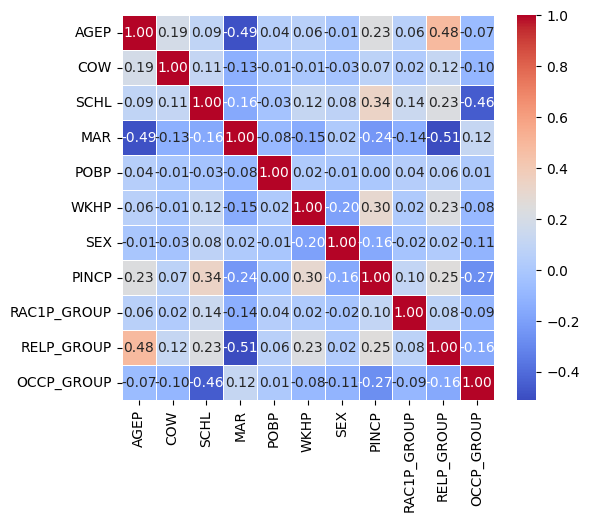

In [29]:
vis_feats_X = income_df_rm_out_group.loc[:, :]
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()

In [30]:

KBest = SelectKBest(score_func=mutual_info_regression, k=10)
output = KBest.fit_transform(income_X_feat, income_y)
top_feats_X = pd.DataFrame(output, columns=KBest.get_feature_names_out())

print(top_feats_X.head())
print(KBest.get_feature_names_out())

   AGEP  SCHL  MAR  POBP  WKHP  RELP_GROUP  OCCP_GROUP  WKHPxAGEP  WKHPxSCHL  \
0  18.0   3.0  5.0  13.0  21.0         0.0        16.0      378.0       63.0   
1  53.0   2.0  5.0  18.0  40.0         0.0        11.0     2120.0       80.0   
2  41.0   2.0  5.0   1.0  40.0         0.0        21.0     1640.0       80.0   
3  18.0   3.0  5.0   1.0   2.0         0.0         9.0       36.0        6.0   
4  21.0   3.0  5.0  12.0  50.0         0.0        12.0     1050.0      150.0   

   AGEPxSCHL  
0       54.0  
1      106.0  
2       82.0  
3       54.0  
4       63.0  
['AGEP' 'SCHL' 'MAR' 'POBP' 'WKHP' 'RELP_GROUP' 'OCCP_GROUP' 'WKHPxAGEP'
 'WKHPxSCHL' 'AGEPxSCHL']


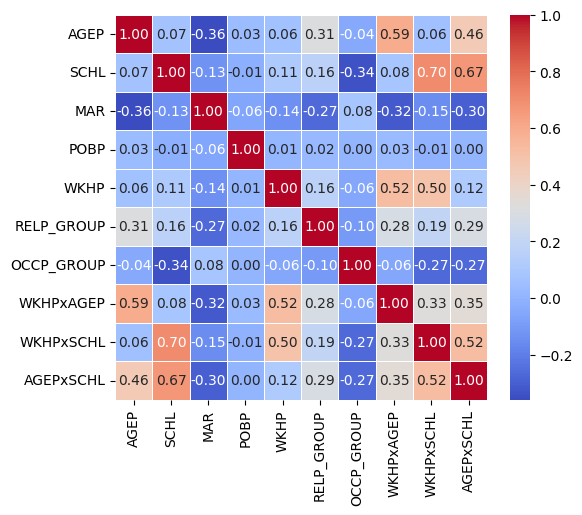

In [31]:

vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('kendall')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


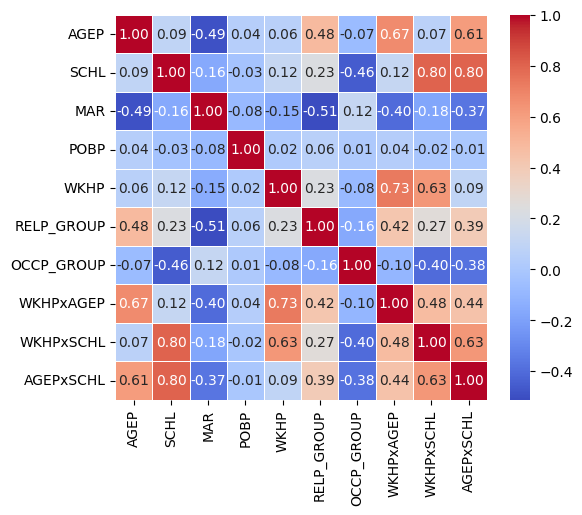

In [32]:

vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


In [33]:
top_feats_X.drop(['AGEP', 'WKHP', 'WKHPxSCHL', 'AGEPxSCHL'], axis=1, inplace=True)

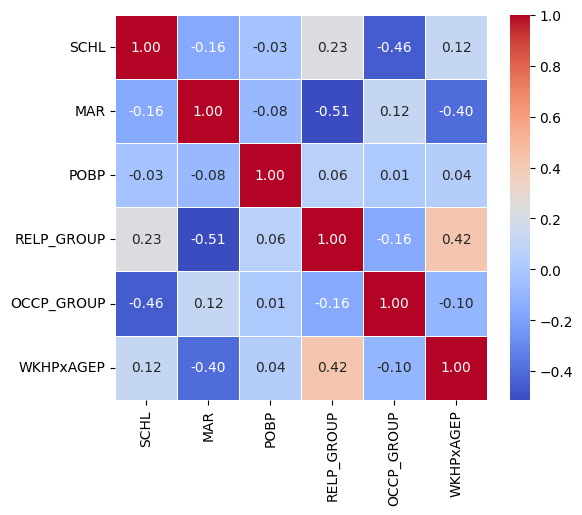

In [34]:

vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


In [35]:
#Split training and test data
X = income_X.copy()
y = income_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

In [36]:
#perform frqeuency map on pobp since too many classes to reduce
freq = X_train['POBP'].value_counts(normalize=True)

X_train['POBP_freq'] = X_train['POBP'].map(freq)
X_test['POBP_freq']  = X_test['POBP'].map(freq)

X_test['POBP_freq'] = X_test['POBP_freq'].fillna(0)

X_train = X_train.drop(columns=['POBP'])
X_test  = X_test.drop(columns=['POBP'])

/tmp/ipykernel_4759/3136798484.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['POBP_freq'] = X_train['POBP'].map(freq)
/tmp/ipykernel_4759/3136798484.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['POBP_freq']  = X_test['POBP'].map(freq)
/tmp/ipykernel_4759/3136798484.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

In [37]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1331464, 51) (332867, 51)
(1331464,) (332867,)


In [38]:
#Normalize and Standardize regression features
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import ColumnTransformer

cols_to_transform = ['AGEP', 'WKHP']

quantile_trans = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
quantile_trans.fit(X_train[cols_to_transform])

stan_X_train = X_train.copy()
stan_X_test = X_test.copy()

# fit on training columns only
stan_X_train[cols_to_transform] = quantile_trans.transform(X_train[cols_to_transform])
stan_X_test[cols_to_transform] = quantile_trans.transform(X_test[cols_to_transform])


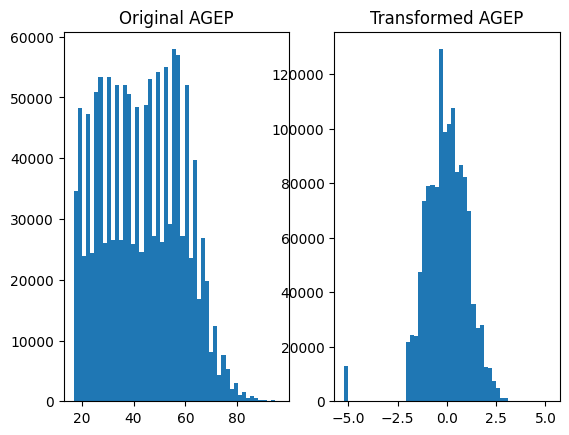

In [39]:
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['AGEP'], bins=50)
plt.title("Original AGEP")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['AGEP'], bins=50)
plt.title("Transformed AGEP")

plt.show()

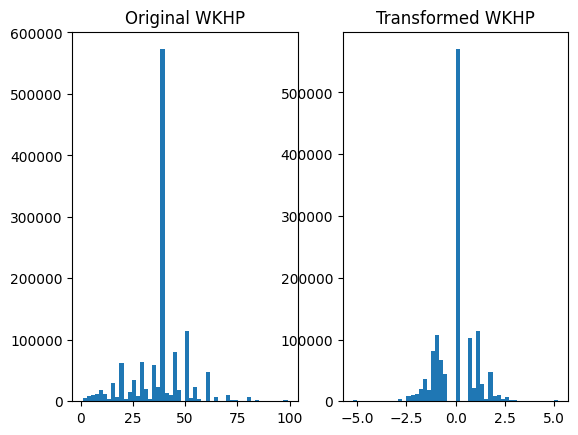

In [40]:
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['WKHP'], bins=50)
plt.title("Original WKHP")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['WKHP'], bins=50)
plt.title("Transformed WKHP")

plt.show()

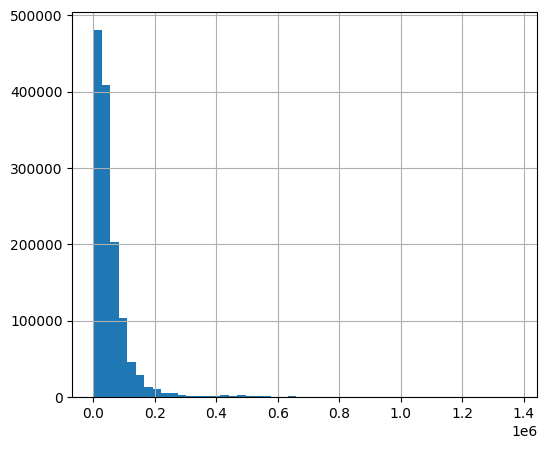

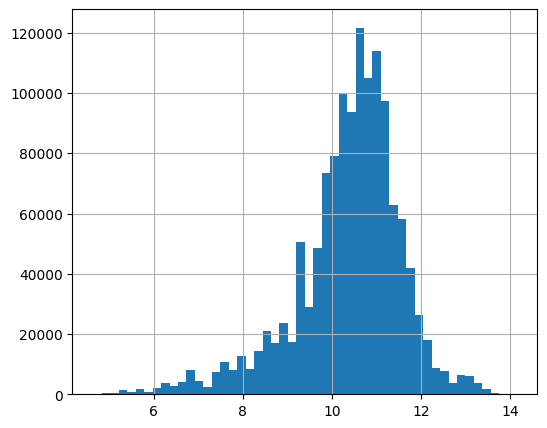

In [41]:
#apply logarithm to target works best tested experimentally
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_train.hist(bins=50, figsize=(6,5))
plt.show()
y_train_log.hist(bins=50, figsize=(6, 5))
plt.show()

In [42]:
#Apply Z-Score Normalization

stdsc_y_scaler = StandardScaler()
stdsc_y_scaler = stdsc_y_scaler.fit(y_train.values.reshape(-1, 1))
standized_y_train = stdsc_y_scaler.transform(y_train.values.reshape(-1, 1))
standized_y_test = stdsc_y_scaler.transform(y_test.values.reshape(-1, 1))


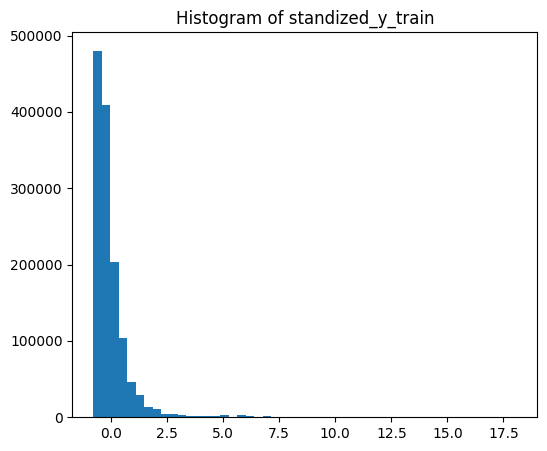

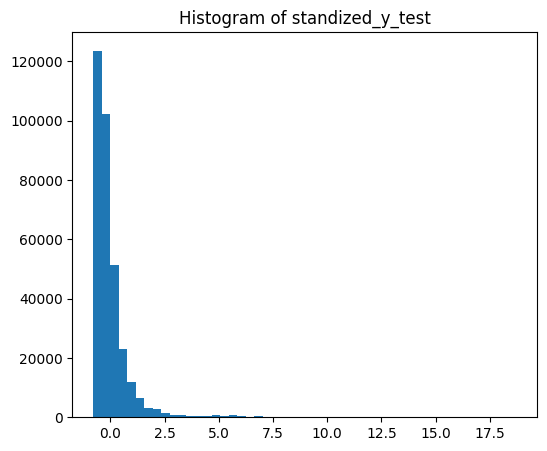

In [43]:

plt.figure(figsize=(6,5))
plt.hist(standized_y_train, bins=50)
plt.title('Histogram of standized_y_train')
plt.show()

plt.figure(figsize=(6,5))
plt.hist(standized_y_test, bins=50)
plt.title('Histogram of standized_y_test')
plt.show()


In [44]:
#Cross Validation Training Metrics Function
def regression_evaluation(X_train, y_train, algorithm, k, scaler=None):
    y_true = np.asarray(y_train).reshape(-1)
    cv_preds = cross_val_predict(algorithm, X_train, y_true, cv=k, method='predict')
    cv_preds = np.asarray(cv_preds).reshape(-1)

    # If a scaler was used, inverse transform first
    if scaler is not None:
        cv_preds = scaler.inverse_transform(cv_preds.reshape(-1, 1)).reshape(-1)
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(-1)

    #when log applied to target
    cv_preds = np.expm1(cv_preds)
    y_true = np.expm1(y_true)

    print("Prediction shape:", cv_preds.shape)

    mse = mean_squared_error(y_true, cv_preds)
    mae = mean_absolute_error(y_true, cv_preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, cv_preds)
    r2 = r2_score(y_true, cv_preds)
    evs = explained_variance_score(y_true, cv_preds)

    y_range = np.max(y_true) - np.min(y_true)
    y_std = np.std(y_true)

    eps = 1e-8

    mae_01_range = mae / (y_range + eps)
    rmse_01_range = rmse / (y_range + eps)
    mse_01_range = mse / ((y_range ** 2) + eps)

    mae_01_std = mae / (y_std + eps)
    rmse_01_std = rmse / (y_std + eps)
    mse_01_std = mse / ((y_std ** 2) + eps)

    #print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    #print(f"MAPE: {mape:.4f}")
    print(f"R^2:  {r2:.4f}")
    #print(f"EVS:  {evs:.4f}")


In [45]:
def testing_evaluation(X_train, X_test, y_train, y_test, algorithm, scaler=None):
  model = algorithm
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # If a scaler was used, inverse transform first
  if scaler is not None:
      y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
      y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

  y_pred = np.expm1(y_pred)
  y_test = np.expm1(y_test)

  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"MAE:  {mae:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R^2:  {r2:.4f}")

  return model

In [46]:
algorithms = {
    "Ridge": Ridge(),
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    #"RandomForest": RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=50, verbose=0, random_state=42),
}
for name, alg in algorithms.items():
  print(name, '\n')
  #nothing applied to target
  regression_evaluation(X_train, y_train_log, alg, 3)
  #testing_evaluation(X_train, X_test, y_train, y_test, alg)
  print('\n')



Ridge 

Prediction shape: (1331464,)
MAE:  28590.9054
RMSE: 63557.9050
R^2:  0.2425


Linear Regression 

Prediction shape: (1331464,)
MAE:  28590.8786
RMSE: 63557.7876
R^2:  0.2425


Lasso 

Prediction shape: (1331464,)
MAE:  34345.7799
RMSE: 72787.6477
R^2:  0.0065


XGBoost 

Prediction shape: (1331464,)
MAE:  25598.1586
RMSE: 59527.8737
R^2:  0.3355


LightGBM 

Prediction shape: (1331464,)
MAE:  25913.1841
RMSE: 60680.6500
R^2:  0.3095


CatBoost 

Prediction shape: (1331464,)
MAE:  25701.3846
RMSE: 59868.7201
R^2:  0.3279




In [47]:
for name, alg in algorithms.items():
  print(name, '\n')
  #nothing applied to target
  #regression_evaluation(X_train, y_train, alg, 3)
  testing_evaluation(X_train, X_test, y_train_log, y_test_log, alg)
  print('\n')

Ridge 

MAE:  28685.6094
RMSE: 63840.5228
R^2:  0.2402


Linear Regression 

MAE:  28685.5881
RMSE: 63840.4318
R^2:  0.2402


Lasso 

MAE:  34318.3173
RMSE: 73003.4469
R^2:  0.0064


XGBoost 

MAE:  25654.6448
RMSE: 59821.2285
R^2:  0.3329


LightGBM 

MAE:  25944.8062
RMSE: 60839.3125
R^2:  0.3100


CatBoost 

MAE:  25759.9305
RMSE: 60176.4522
R^2:  0.3249




In [48]:
def train_ensemble(X_train, y_train_log, X_val, y_val_log):
    """
    Train XGBoost, LightGBM, and CatBoost on log-transformed targets,
    then convert predictions back to original scale for evaluation.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, r2_score

    models = {}
    predictions = {}

    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

    y_val = np.expm1(y_val_log)

    # ===== XGBoost Model =====
    print("Training XGBoost...")
    xgb_model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        verbosity=0,
        early_stopping_rounds=100
    )

    xgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        verbose=False
    )

    xgb_preds_log = xgb_model.predict(X_val_np)
    xgb_preds = np.expm1(xgb_preds_log)
    xgb_mae = mean_absolute_error(y_val, xgb_preds)
    xgb_r2 = r2_score(y_val, xgb_preds)
    print(f"XGBoost - MAE: {xgb_mae:.4f}, R²: {xgb_r2:.4f}")

    models['xgb'] = xgb_model
    predictions['xgb'] = xgb_preds

    # ===== LightGBM Model =====
    print("Training LightGBM...")
    lgb_model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    lgb_preds_log = lgb_model.predict(X_val_np)
    lgb_preds = np.expm1(lgb_preds_log)
    lgb_mae = mean_absolute_error(y_val, lgb_preds)
    lgb_r2 = r2_score(y_val, lgb_preds)
    print(f"LightGBM - MAE: {lgb_mae:.4f}, R²: {lgb_r2:.4f}")

    models['lgb'] = lgb_model
    predictions['lgb'] = lgb_preds

    # ===== CatBoost Model =====
    print("Training CatBoost...")
    cb_model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.1,
        depth=6,
        subsample=0.8,
        reg_lambda=10,
        random_state=42,
        verbose=0
    )

    cb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        early_stopping_rounds=100,
        verbose=False
    )

    cb_preds_log = cb_model.predict(X_val_np)
    cb_preds = np.expm1(cb_preds_log)
    cb_mae = mean_absolute_error(y_val, cb_preds)
    cb_r2 = r2_score(y_val, cb_preds)
    print(f"CatBoost - MAE: {cb_mae:.4f}, R²: {cb_r2:.4f}")

    models['catboost'] = cb_model
    predictions['catboost'] = cb_preds

    # ===== Ensemble Predictions =====
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    #ensemble_preds = 0.3 * xgb_preds + 0.4 * lgb_preds + 0.3 * cb_preds
    ensemble_mae = mean_absolute_error(y_val, ensemble_preds)
    ensemble_r2 = r2_score(y_val, ensemble_preds)
    print(f"\nENSEMBLE (Average) - MAE: {ensemble_mae:.4f}, R²: {ensemble_r2:.4f}")
    print(f"Ensemble improvement over best single model: {ensemble_r2 - max(xgb_r2, lgb_r2, cb_r2):.4f} R² change")

    predictions['ensemble'] = ensemble_preds

    return models, predictions

In [49]:
def final_test_evaluation(models_dict, X_train, X_test, y_train_log, y_test_log):
    """
    Evaluates models when target was trained as log1p(y).
    Predictions and y_test are converted back to original dollar scale.
    """

    print("\n" + "="*80)
    print("FINAL TEST SET EVALUATION")
    print("="*80)

    X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

    # Convert y_test back to original scale
    y_test_actual = np.expm1(y_test_log)

    def evaluate_model(model_name, model):
        print(f"Evaluating {model_name} on test set...")

        # Predict in log scale
        preds_log = model.predict(X_test_np)

        # Convert predictions back to original scale
        preds_actual = np.expm1(preds_log)

        mae = mean_absolute_error(y_test_actual, preds_actual)
        r2 = r2_score(y_test_actual, preds_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))

        # safer MAPE to avoid divide-by-zero issues
        nonzero_mask = y_test_actual != 0
        mape = np.mean(
            np.abs(
                (y_test_actual[nonzero_mask] - preds_actual[nonzero_mask])
                / y_test_actual[nonzero_mask]
            )
        )

        return preds_actual, mae, r2, rmse, mape

    xgb_preds, xgb_mae, xgb_r2, xgb_rmse, xgb_mape = evaluate_model(
        "XGBoost", models_dict['xgb']
    )

    lgb_preds, lgb_mae, lgb_r2, lgb_rmse, lgb_mape = evaluate_model(
        "LightGBM", models_dict['lgb']
    )

    cb_preds, cb_mae, cb_r2, cb_rmse, cb_mape = evaluate_model(
        "CatBoost", models_dict['catboost']
    )

    print("Evaluating ENSEMBLE on test set...")

    # ensemble in ORIGINAL scale
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    #ensemble_preds = 0.3 * xgb_preds + 0.4 * lgb_preds + 0.3 * cb_preds

    ensemble_mae = mean_absolute_error(y_test_actual, ensemble_preds)
    ensemble_r2 = r2_score(y_test_actual, ensemble_preds)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test_actual, ensemble_preds))

    nonzero_mask = y_test_actual != 0
    ensemble_mape = np.mean(
        np.abs(
            (y_test_actual[nonzero_mask] - ensemble_preds[nonzero_mask])
            / y_test_actual[nonzero_mask]
        )
    )

    test_results = {
        'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble'],
        'MAE': [xgb_mae, lgb_mae, cb_mae, ensemble_mae],
        'R²': [xgb_r2, lgb_r2, cb_r2, ensemble_r2],
        'RMSE': [xgb_rmse, lgb_rmse, cb_rmse, ensemble_rmse],
        'MAPE': [xgb_mape, lgb_mape, cb_mape, ensemble_mape]
    }

    summary_df = pd.DataFrame(test_results)

    print("\n" + "="*80)
    print("TEST SET RESULTS — ORIGINAL TARGET SCALE")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("="*80)

    return test_results, summary_df

In [50]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train_log, test_size=0.2, random_state=42)

models_dict, val_predictions = train_ensemble(X_tr, y_tr, X_val, y_val)


Training XGBoost...
XGBoost - MAE: 25133.6524, R²: 0.3487
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1200]	valid_0's l2: 0.543458


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - MAE: 25161.1316, R²: 0.3469
Training CatBoost...
CatBoost - MAE: 25203.2073, R²: 0.3434

ENSEMBLE (Average) - MAE: 25131.9937, R²: 0.3470
Ensemble improvement over best single model: -0.0017 R² change


In [51]:
test_results_final, summary_table = final_test_evaluation(
    models_dict, X_tr, X_test, y_tr, y_test_log
)


FINAL TEST SET EVALUATION
Evaluating XGBoost on test set...
Evaluating LightGBM on test set...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Evaluating CatBoost on test set...
Evaluating ENSEMBLE on test set...

TEST SET RESULTS — ORIGINAL TARGET SCALE
   Model          MAE       R²         RMSE     MAPE
 XGBoost 25296.038332 0.348449 59118.291413 0.845241
LightGBM 25325.565233 0.346555 59204.152733 0.846798
CatBoost 25356.181383 0.343381 59347.759035 0.848117
Ensemble 25292.479896 0.346756 59195.054193 0.845807


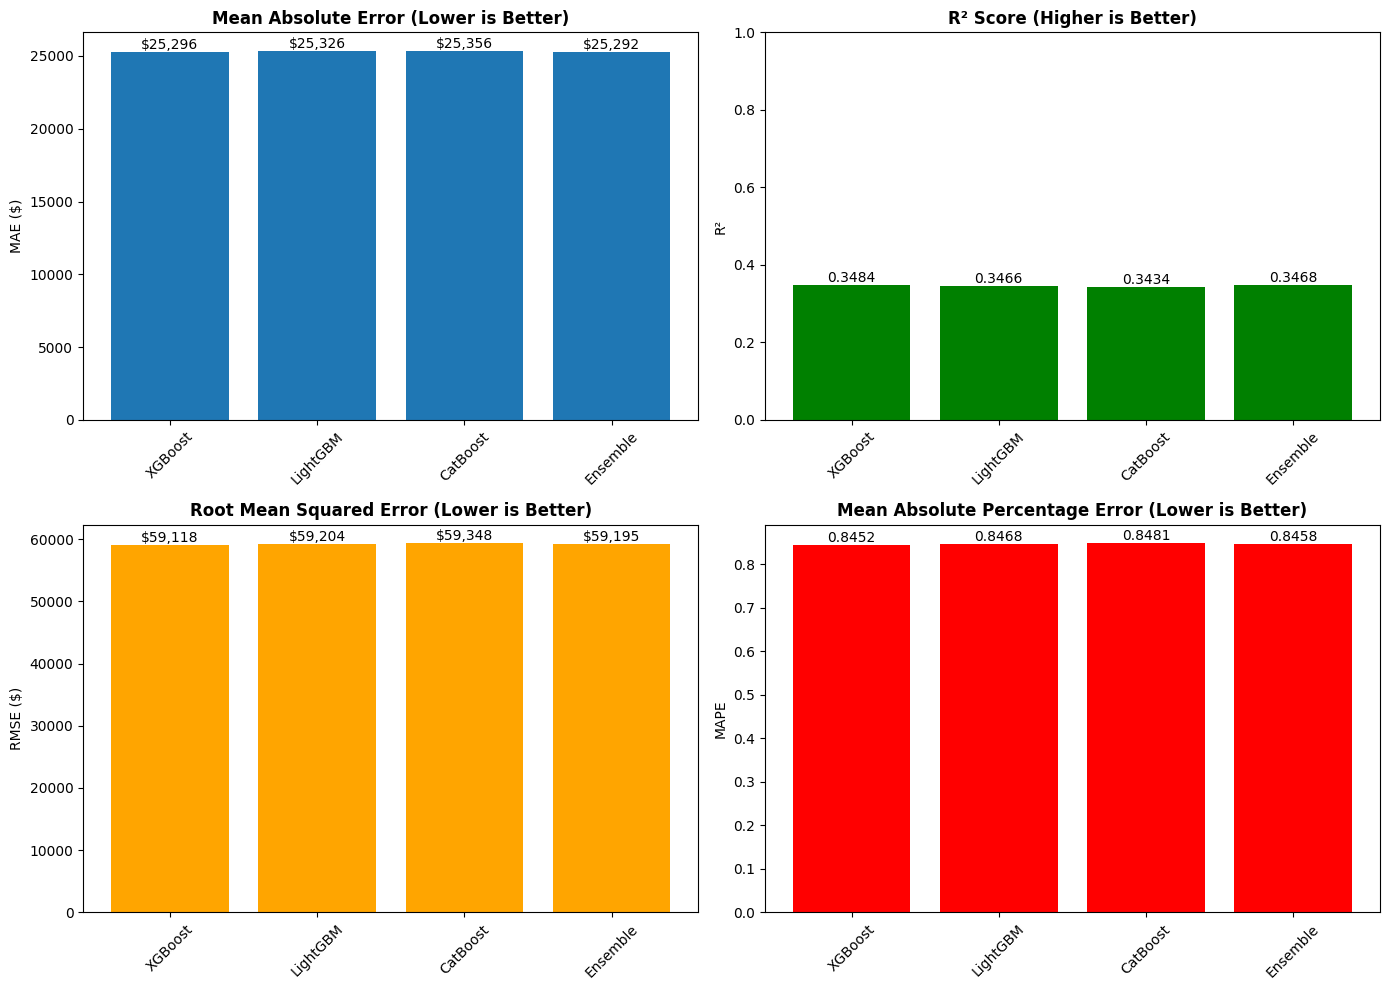

✓ Model performance comparison chart displayed


In [52]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE Comparison
axes[0, 0].bar(summary_table['Model'], summary_table['MAE'])
axes[0, 0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAE']):
    axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 2: R² Comparison
axes[0, 1].bar(summary_table['Model'], summary_table['R²'], color='green')
axes[0, 1].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['R²']):
    axes[0, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

# Plot 3: RMSE Comparison
axes[1, 0].bar(summary_table['Model'], summary_table['RMSE'], color='orange')
axes[1, 0].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['RMSE']):
    axes[1, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 4: MAPE Comparison
axes[1, 1].bar(summary_table['Model'], summary_table['MAPE'], color='red')
axes[1, 1].set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MAPE')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAPE']):
    axes[1, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("✓ Model performance comparison chart displayed")


In [53]:
import joblib

artifact = {
    "models": models_dict,
    "cols_to_transform": cols_to_transform,
    "relp_ordinal_encoder": ordinal_relp,
    "race_ordinal_encoder": ordinal_race,
    "occp_ordinal_encoder": ordinal,
    "pobp_frequency_map": freq,
    "feature_columns": X_train.columns.tolist(),
    "relp_categories": relp_order,
    "race_categories": race_order,
    "occp_categories": ordinal.categories_
}
joblib.dump(artifact, "income_pipeline.pkl")

['income_pipeline.pkl']

In [54]:
from google.colab import drive
drive.mount('/content/drive')

joblib.dump(artifact, "/content/drive/MyDrive/income_pipeline.pkl")

Mounted at /content/drive


['/content/drive/MyDrive/income_pipeline.pkl']